# 1D bar full pipeline

This notebook mirrors `scripts/run_bar1d_full_pipeline.py` using the `analytic` backend so it can run in a regular Jupyter kernel without FEniCSx.

It computes the deterministic solution, Monte Carlo prior UQ, PCE prior UQ, synthetic observations, hyperparameter estimation, and posterior summary, then stores the result in `results/case_7.ipynb.npz`.

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI

from statFEMx.config import Bar1DConfig
from statFEMx.fem.bar1d import solve_bar_1d
from statFEMx.statfem.bar1d import (
    build_projection_matrix,
    compute_posterior,
    estimate_hyperparameters,
    generate_synthetic_observations,
)
from statFEMx.uq.bar1d_mc import run_bar1d_mc
from statFEMx.uq.bar1d_pce import run_bar1d_pce


In [22]:
backend = "analytic"
obs_case = "nonlinear"
cal_case = 7
output_path = Path("results/case_7.ipynb.npz")

cfg = Bar1DConfig()
comm = MPI.COMM_SELF


In [23]:
det = solve_bar_1d(cfg, cfg.mean_youngs_modulus, backend=backend, comm=MPI.COMM_SELF)
mc = run_bar1d_mc(cfg, backend=backend, comm=comm)
pce = run_bar1d_pce(cfg, backend=backend, comm=comm)

obs = generate_synthetic_observations(cfg, obs_case=obs_case, cal_case=cal_case)
P, P_active = build_projection_matrix(cfg, obs.sensor_coordinates)

hp = estimate_hyperparameters(
    C_u_active_pc=pce.covariance[1:, 1:],
    P_active=P_active,
    C_e=obs.C_e,
    y_obs=obs.y_obs,
    mu_u_active_pc=pce.mean[1:],
    sensor_coordinates=obs.sensor_coordinates,
    nrep=obs.nrep,
)

posterior = compute_posterior(
    cfg,
    mu_u_active_pc=pce.mean[1:],
    C_u_active_pc=pce.covariance[1:, 1:],
    P_active=P_active,
    y_obs=obs.y_obs,
    C_e=obs.C_e,
    C_d=hp.C_d,
    rho=hp.rho,
    nrep=obs.nrep,
)

output_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    output_path,
    node_coordinates=det.node_coordinates,
    deterministic_displacement=det.displacement,
    mc_mean=mc.mean,
    mc_std=mc.std,
    mc_tip_samples=mc.tip_samples,
    pce_mean=pce.mean,
    pce_covariance=pce.covariance,
    pce_tip_samples=pce.tip_samples,
    sensor_coordinates=obs.sensor_coordinates,
    y_obs=obs.y_obs,
    projection_matrix=P,
    rho=hp.rho,
    sig_d=hp.sig_d,
    l_d=hp.l_d,
    posterior_mean=posterior.mu_u_y,
    posterior_covariance=posterior.C_u_y,
    posterior_ci=posterior.ci_u_y,
    measurement_mean=posterior.mu_z,
    measurement_covariance=posterior.C_z,
    measurement_ci=posterior.ci_z,
)

print(f"saved {output_path}")
print(f"rho={hp.rho:.6f}, sig_d={hp.sig_d:.6f}, l_d={hp.l_d:.6f}")
print(f"MC tip mean={mc.mean[-1]:.6f}, PCE tip mean={pce.mean[-1]:.6f}")


saved results/case_7.ipynb.npz
rho=0.415917, sig_d=1.097535, l_d=2.330874
MC tip mean=20.070070, PCE tip mean=20.112500


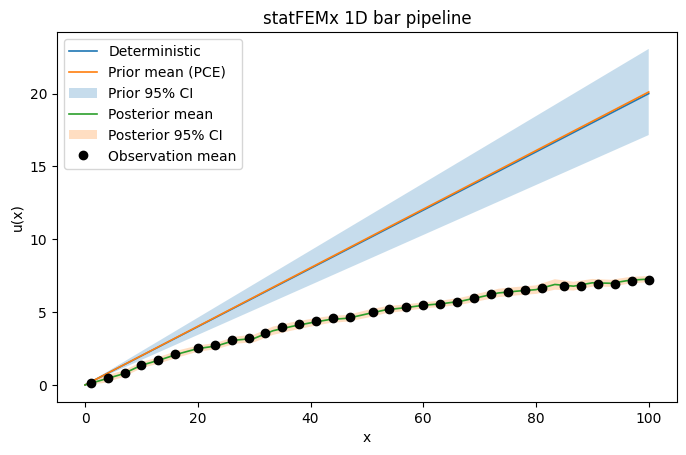

In [24]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 4.8))
x = det.node_coordinates
prior_std = np.sqrt(np.maximum(np.diag(pce.covariance), 0.0))

ax.plot(x, det.displacement, linewidth=1.2, label="Deterministic")
ax.plot(x, pce.mean, linewidth=1.2, label="Prior mean (PCE)")
ax.fill_between(x, pce.mean - 1.96 * prior_std, pce.mean + 1.96 * prior_std, alpha=0.25, label="Prior 95% CI")
ax.plot(x, posterior.mu_u_y, linewidth=1.2, label="Posterior mean")
ax.fill_between(x, posterior.mu_u_y - posterior.ci_u_y, posterior.mu_u_y + posterior.ci_u_y, alpha=0.25, label="Posterior 95% CI")
ax.plot(obs.sensor_coordinates, obs.y_obs.mean(axis=1), "o", color="black", label="Observation mean")
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("statFEMx 1D bar pipeline")
ax.legend(loc="best")
ax.grid(False)
plt.show()
